<a href="https://colab.research.google.com/github/benhidalgov/Mineriadedatos/blob/main/Entrega_1_mineria_de_datos_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploración y Preprocesamiento de Datos (EPL Dataset)
Este notebook replica la fase de Análisis Exploratorio de Datos (EDA) y preprocesamiento de variables para el dataset de la English Premier League (`epl_final.csv`).

**Objetivos:**
- Cargar los datos y revisar la estructura del dataset.
- Realizar un mapeo sistemático de los tipos de datos.
- Aplicar técnicas de codificación para variables categóricas de alta y baja cardinalidad.
- Visualizar relaciones y distribuciones clave.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
!pip install category_encoders
import category_encoders as ce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.4 MB/s eta 0:00:00


In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("epl_final.csv") # creamos un dataframe llamado df y cargamos el dataset csv

### 1. Inspección Inicial del Dataset
El siguiente bloque carga las primeras filas para observar la estructura general del dataset, los nombres de las columnas y el formato de los datos que contiene.


In [ ]:
df.head() # visualizamos las primeras 5 filas


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,17,8,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,17,12,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,6,16,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,6,13,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,17,12,8,6,6,4,21,20,1,3,0,0


**Interpretación:** La función `head()` nos permite confirmar que los datos se han cargado correctamente. Podemos observar columnas categóricas (como equipos y resultados) y numéricas (como goles y tiros). A continuación vemos las últimas filas con `tail()`.


In [ ]:
df.tail()# visualizamos las ultimas 5 filas

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
9375,2024/25,2025-05-04,Brentford,Man United,4,3,H,2,1,H,12,14,6,5,7,4,8,10,0,2,0,0
9376,2024/25,2025-05-04,Brighton,Newcastle,1,1,D,1,0,H,5,13,2,5,1,4,15,10,2,1,0,0
9377,2024/25,2025-05-04,West Ham,Tottenham,1,1,D,1,1,D,11,7,2,2,1,3,18,15,2,2,0,0
9378,2024/25,2025-05-04,Chelsea,Liverpool,3,1,H,1,0,H,17,11,7,2,3,6,10,11,2,2,0,0
9379,2024/25,2025-05-05,Crystal Palace,Nott'm Forest,1,1,D,0,0,D,20,12,3,4,7,4,9,15,3,8,0,0


**Interpretación:** `tail()` nos muestra el final del dataset, confirmando que la estructura se mantiene consistente hasta el último registro.


In [ ]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(9380, 22)

### 2. Dimensión y Tipos de Datos
Conocer el tamaño del dataset es crucial para entender la cantidad de información disponible. La función `shape` nos dirá filas y columnas.


In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
Season,object
MatchDate,object
HomeTeam,object
AwayTeam,object
FullTimeHomeGoals,int64
FullTimeAwayGoals,int64
FullTimeResult,object
HalfTimeHomeGoals,int64
HalfTimeAwayGoals,int64
HalfTimeResult,object


**Interpretación:** El resultado de `shape` nos indica que tenemos 9380 observaciones (filas) y 22 características (columnas). A continuación usamos `dtypes` para analizar qué tipo de dato informático asignó Pandas a cada columna y `isnull().sum()` para verificar nulos.


In [ ]:
df.isnull().sum() #contamos la cantidad de nulos por columna // no notamos nulos en este dataset

,0
Season,0
MatchDate,0
HomeTeam,0
AwayTeam,0
FullTimeHomeGoals,0
FullTimeAwayGoals,0
FullTimeResult,0
HalfTimeHomeGoals,0
HalfTimeAwayGoals,0
HalfTimeResult,0


**Interpretación (`dtypes` y `isnull()`):**
- **Tipos de datos informáticos:** Pandas asignó tipo `object` a las variables categóricas (cadenas de texto como `HomeTeam`, `FullTimeResult`) y tipo `int64` a las variables numéricas (como `HomeShots`). Esto es correcto ya que los goles, tiros, tarjetas, etc. son valores discretos que no requieren decimales.
- **Valores nulos:** La función `isnull().sum()` confirma que **no hay valores nulos** en ninguna de las columnas, por lo que no es necesario aplicar técnicas de imputación.

---
### 3. Mapeo de Datos de las Columnas
Por buena práctica, definimos a continuación la naturaleza de cada variable (clasificación estadística y tipo de dato informático):

| Variable | Tipo de Dato (Pandas) | Clasificación Estadística |
| :--- | :--- | :--- |
| `Season` | object | Categórico Ordinal / Nominal |
| `MatchDate` | object | Categórico (Fecha) |
| `HomeTeam`, `AwayTeam` | object | Categórico Nominal |
| `FullTimeResult`, `HalfTimeResult` | object | Categórico Nominal |
| `FullTimeHomeGoals`, `FullTimeAwayGoals` | int64 | Numérico Discreto |
| `HalfTimeHomeGoals`, `HalfTimeAwayGoals` | int64 | Numérico Discreto |
| `HomeShots`, `AwayShots` | int64 | Numérico Discreto |
| `HomeShotsOnTarget`, `AwayShotsOnTarget` | int64 | Numérico Discreto |
| `HomeCorners`, `AwayCorners` | int64 | Numérico Discreto |
| `HomeFouls`, `AwayFouls` | int64 | Numérico Discreto |
| `HomeYellowCards`, `AwayYellowCards` | int64 | Numérico Discreto |
| `HomeRedCards`, `AwayRedCards` | int64 | Numérico Discreto |
---


In [ ]:
cant_cat_col_hometeam_df = df['HomeTeam'].value_counts() # nos mostrará la cantidad de categoricas distintas unicas de HomeTeam
print(cant_cat_col_hometeam_df)
print(f"cantidad HomeTeam: {cant_cat_col_hometeam_df.count()}") # tenemos 46 categorias distintas de equipos

HomeTeam
Everton             471
Chelsea             469
Tottenham           469
Man United          469
Arsenal             468
Liverpool           467
Man City            450
Newcastle           430
West Ham            417
Aston Villa         412
Fulham              335
Southampton         318
Sunderland          266
Leicester           245
Crystal Palace      244
West Brom           244
Blackburn           204
Bolton              204
Wolves              204
Stoke               190
Middlesbrough       187
Burnley             171
Wigan               152
Brighton            151
Bournemouth         150
Watford             133
Swansea             133
Leeds               131
Norwich             131
Birmingham          130
Charlton            128
Portsmouth          128
Hull                 95
Sheffield United     76
Brentford            75
Reading              57
QPR                  57
Derby                57
Ipswich              55
Nott'm Forest        55
Huddersfield         38
Cardiff

In [ ]:
cant_cat_col_ftr_df = df['FullTimeResult'].value_counts() # nos mostrará la cantidad de categoricas distintas unicas de FullTimeResult
print(cant_cat_col_ftr_df)
print(f"cantidad FullTimeResult: {cant_cat_col_ftr_df.count()}")

FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64
cantidad FullTimeResult: 3


**Interpretación Cardinalidad:** Comprobamos que hay 46 equipos únicos tanto para Local como Visitante, lo cual representa una **alta cardinalidad**. Para los resultados (`FullTimeResult`) solo hay 3 categorías únicas (H, D, A), lo que indica **baja cardinalidad**.

A continuación, usamos `describe()` para ver la estadística descriptiva de los valores numéricos del dataframe.


In [ ]:
df.describe()

,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


**Interpretación de `describe()`:** Podemos observar en los estadísticos que el promedio de goles del equipo local (`FullTimeHomeGoals`) es ligeramente superior al del equipo visitante (`FullTimeAwayGoals`), lo cual es consistente con la "ventaja de jugar en casa" en el fútbol. Las desviaciones estándar y rangos intercuartílicos son coherentes, sin valores máximos irracionales que indiquen outliers severos.

---
### 4. Codificación de Variables Categóricas (Encoding)
Los modelos de Machine Learning requieren datos matemáticos y no pueden procesar directamente variables de texto (object).

**Justificación One-Hot Encoding:** Usaremos **One-Hot Encoding** para los resultados (`FullTimeResult` y `HalfTimeResult`) porque tienen una **baja cardinalidad** (solo 3 categorías). Esto creará 3 columnas binarias sin asumir ningún orden de jerarquía o importancia.


In [ ]:
# 1. OneHot Encoding para 'FullTimeResult' y 'HalfTimeResult' (baja cardinalidad)
ohe = OneHotEncoder(sparse_output=False)
ftr_htr_encoded = ohe.fit_transform(df[['FullTimeResult', 'HalfTimeResult']])

In [ ]:
# Convertimos el resultado en un DataFrame con nombres de columnas claros
ftr_htr_df = pd.DataFrame(
    ftr_htr_encoded,
    columns=ohe.get_feature_names_out(['FullTimeResult', 'HalfTimeResult']),
    index=df.index
)

**Justificación Binary Encoding:** Usaremos **Binary Encoding** para `HomeTeam` y `AwayTeam`. Al tener una **alta cardinalidad** (46 equipos), usar One-Hot Encoding generaría un exceso de nuevas variables (92 columnas en total), causando un problema de dimensionalidad. Binary Encoding transforma las categorías a números binarios reduciendo de forma muy eficiente la cantidad de características nuevas generadas.


In [ ]:
# 2. Binary Encoding para 'HomeTeam' y 'AwayTeam' usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como los equipos (46 categorias)
be = ce.BinaryEncoder(cols=['HomeTeam', 'AwayTeam'])
df_binary = be.fit_transform(df[['HomeTeam', 'AwayTeam']])

In [ ]:
# 3. Concatenar todo y eliminar las columnas originales categoricas
# Unimos el dataframe original con las nuevas columnas
cols_to_drop = ['FullTimeResult', 'HalfTimeResult', 'HomeTeam', 'AwayTeam', 'Season', 'MatchDate']
df_final = pd.concat([df.drop(columns=cols_to_drop), ftr_htr_df, df_binary], axis=1)


**Interpretación Concatenación:** Hemos creado exitosamente `df_final` eliminando las columnas originales categóricas y concatenando las nuevas representaciones numéricas generadas por los dos encoders.


In [ ]:
# 4. Ver los cambios
print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")


   FullTimeHomeGoals  FullTimeAwayGoals  HalfTimeHomeGoals  HalfTimeAwayGoals  \
0                  4                  0                  2                  0   
1                  4                  2                  1                  0   
2                  1                  3                  1                  1   
3                  2                  2                  1                  2   
4                  2                  0                  2                  0   

   HomeShots  AwayShots  HomeShotsOnTarget  AwayShotsOnTarget  HomeCorners  \
0         17          8                 14                  4            6   
1         17         12                 10                  5            7   
2          6         16                  3                  9            8   
3          6         13                  4                  6            5   
4         17         12                  8                  6            6   

   AwayCorners  HomeFouls  AwayFouls  HomeYe

**Interpretación de Codificación Final:** Como podemos observar en el output, todas las características están ahora convertidas a variables numéricas y están listas para ser ingresadas a algoritmos de Machine Learning. El número total de columnas aumentó, pero de forma controlada.

---
### 5. Análisis Visual (EDA Visual)
El siguiente bloque crea gráficas para interpretar el comportamiento de la liga y la relación entre las variables generadas.


In [ ]:
# Visualización de Datos (Gráficas)
# 1. Distribución de Resultados a Tiempo Completo (FullTimeResult)
# H = Home Win (Victoria del local), A = Away Win (Victoria del visitante), D = Draw(Empate)

In [ ]:
plt.figure(figsize=(8, 5))
# Creamos una copia de la columna temporalmente y le cambiamos los nombres (apodos)
resultados_nombres = df['FullTimeResult'].map({
    'H': 'Victoria Local',
    'D': 'Empate',
    'A': 'Victoria Visitante'
})



<Figure size 800x500 with 0 Axes>

/tmp/ipykernel_8226/3050371642.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=resultados_nombres, palette='viridis')


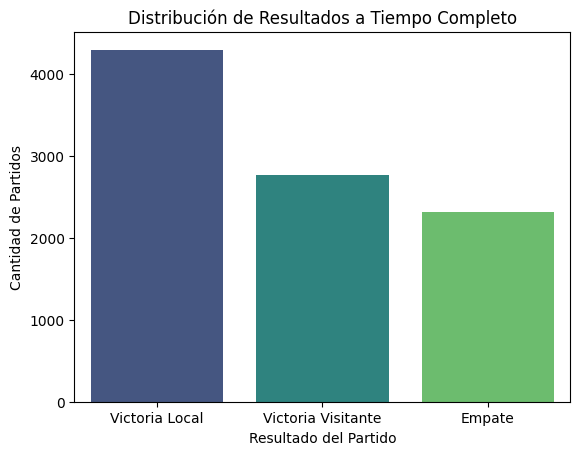

In [ ]:
sb.countplot(x=resultados_nombres, palette='viridis')
plt.title('Distribución de Resultados a Tiempo Completo')
plt.xlabel('Resultado del Partido')
plt.ylabel('Cantidad de Partidos')
plt.show()

**Interpretación (Distribución de Resultados):** El gráfico de barras confirma visualmente que la **Victoria Local** es el resultado más frecuente en la liga de forma histórica, seguido de la victoria del visitante y por último el empate. Esto demuestra que la variable a predecir no está perfectamente balanceada.


/tmp/ipykernel_8226/2807724115.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df, x='FullTimeHomeGoals', y='HomeShotsOnTarget', palette='Reds')


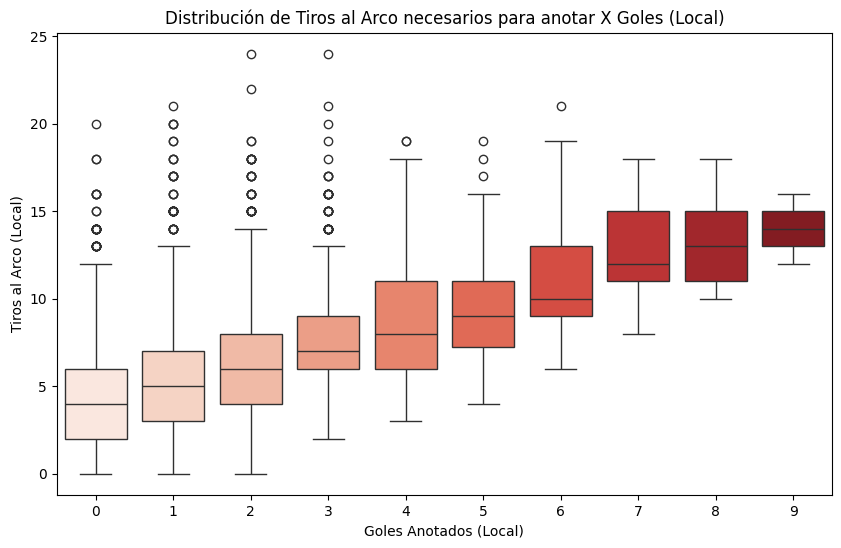

In [ ]:
# 3. Relación entre Tiros al Arco del Local y Goles del Local
plt.figure(figsize=(10, 6))
sb.boxplot(data=df, x='FullTimeHomeGoals', y='HomeShotsOnTarget', palette='Reds')
plt.title('Distribución de Tiros al Arco necesarios para anotar X Goles (Local)')
plt.xlabel('Goles Anotados (Local)')
plt.ylabel('Tiros al Arco (Local)')
plt.show()


**Interpretación (Goles vs Tiros al Arco):** Este gráfico de cajas (boxplot) ilustra que, como dicta la lógica, a mayor número de goles anotados, suele ser necesario un mayor número de tiros al arco. Muestra muy claramente el rango (cuartiles) de tiros necesarios por un equipo local para conseguir 1, 2, 3 o más goles, así como algunos valores atípicos (equipos que anotaron mucho con pocos tiros o viceversa).


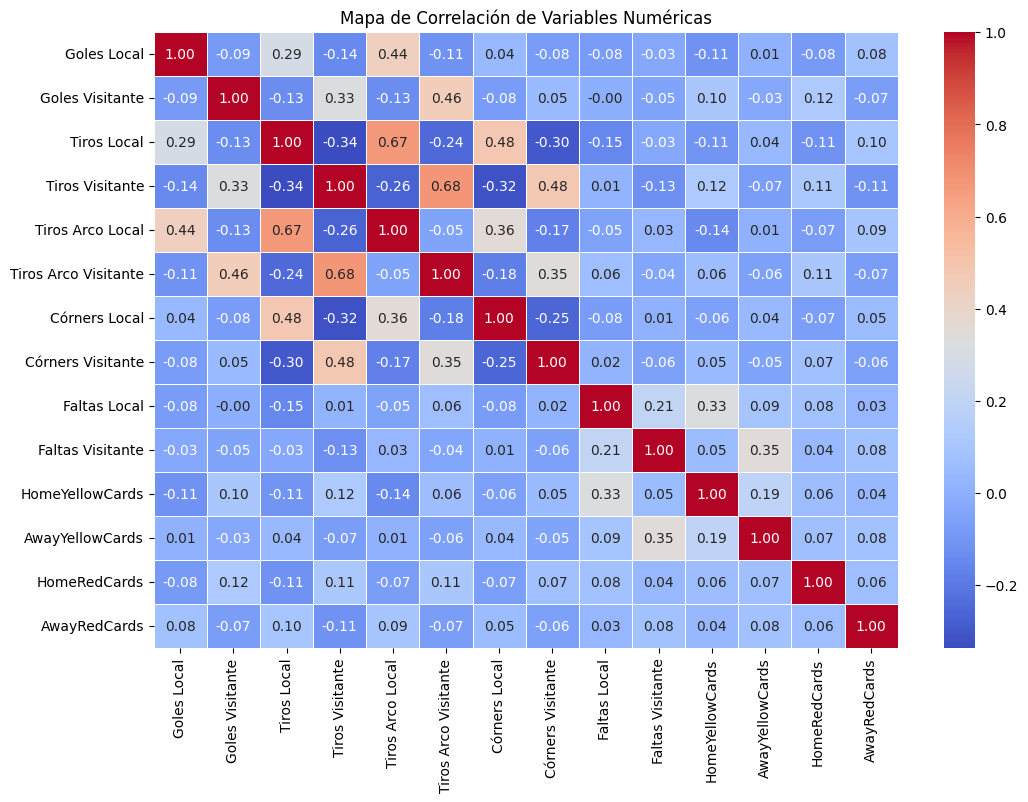

In [ ]:
# Diccionario para traducir los nombres a español en la gráfica
nombres_espanol = {
    'FullTimeHomeGoals': 'Goles Local',
    'FullTimeAwayGoals': 'Goles Visitante',
    'HomeShots': 'Tiros Local',
    'AwayShots': 'Tiros Visitante',
    'HomeShotsOnTarget': 'Tiros Arco Local',
    'AwayShotsOnTarget': 'Tiros Arco Visitante',
    'HomeCorners': 'Córners Local',
    'AwayCorners': 'Córners Visitante',
    'HomeFouls': 'Faltas Local',
    'AwayFouls': 'Faltas Visitante'
}

num_cols = [
    'FullTimeHomeGoals', 'FullTimeAwayGoals', 'HomeShots', 'AwayShots',
    'HomeShotsOnTarget', 'AwayShotsOnTarget', 'HomeCorners', 'AwayCorners',
    'HomeFouls', 'AwayFouls', 'HomeYellowCards', 'AwayYellowCards',
    'HomeRedCards', 'AwayRedCards'
]

plt.figure(figsize=(12, 8))
correlation_matrix = df[num_cols].corr().rename(index=nombres_espanol, columns=nombres_espanol)

sb.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()

**Interpretación (Matriz de Correlación):** El mapa de calor (heatmap) mide la fuerza de la relación lineal entre variables numéricas. Podemos observar altas correlaciones positivas entre eventos lógicos: tiros a puerta (`Tiros Arco Local`) y goles marcados (`Goles Local`). Las correlaciones entre eventos del equipo local y eventos del visitante suelen ser cercanas a cero, lo que implica que lo que hace uno no dictamina estrictamente el total del otro.


/tmp/ipykernel_17155/1539290480.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=top_10_teams.values, y=top_10_teams.index, palette='magma')


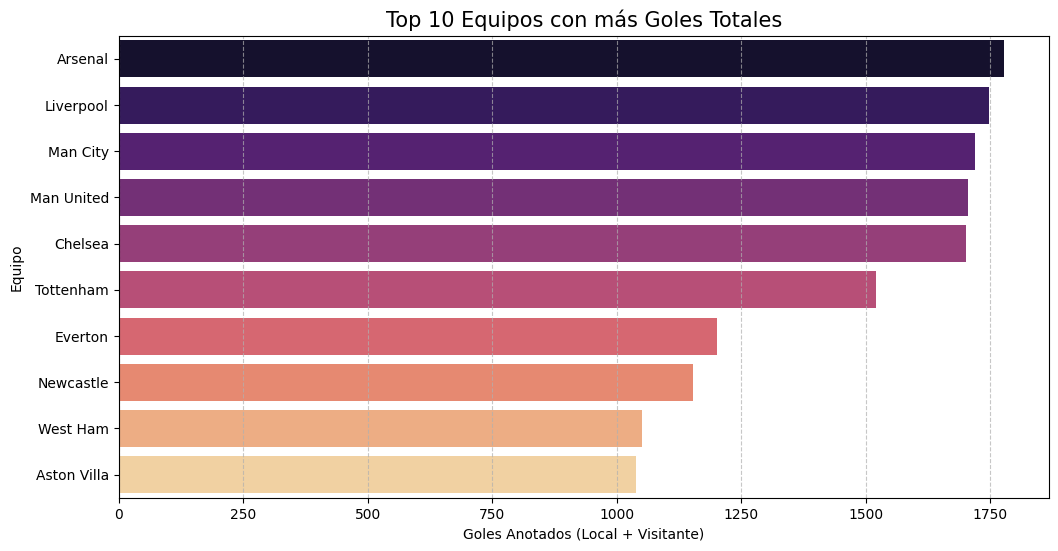

In [ ]:
# 1. Preparación de datos por equipo
# Sumamos goles anotados como local y como visitante para cada equipo
home_goals = df.groupby('HomeTeam')['FullTimeHomeGoals'].sum()
away_goals = df.groupby('AwayTeam')['FullTimeAwayGoals'].sum()
total_goals = (home_goals + away_goals).sort_values(ascending=False)

# Seleccionamos el Top 10
top_10_teams = total_goals.head(10)

# 2. Visualización: Top 10 Equipos más Goleadores
plt.figure(figsize=(12, 6))
sb.barplot(x=top_10_teams.values, y=top_10_teams.index, palette='magma')
plt.title('Top 10 Equipos con más Goles Totales', fontsize=15)
plt.xlabel('Goles Anotados (Local + Visitante)')
plt.ylabel('Equipo')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Interpretación (Top 10 Goleadores):** La gráfica de barras muestra horizontalmente a los 10 equipos más prolíficos de la liga, combinando su desempeño. Esto permite identificar rápidamente las franquicias que tienen mayor "peso" ofensivo en la Premier League.

A continuación, analizaremos la distribución de frecuencia para estos mismos equipos top 10 jugando de local (para revisar si sus goles totales se deben a rachas puntuales o si mantienen un promedio consistente).


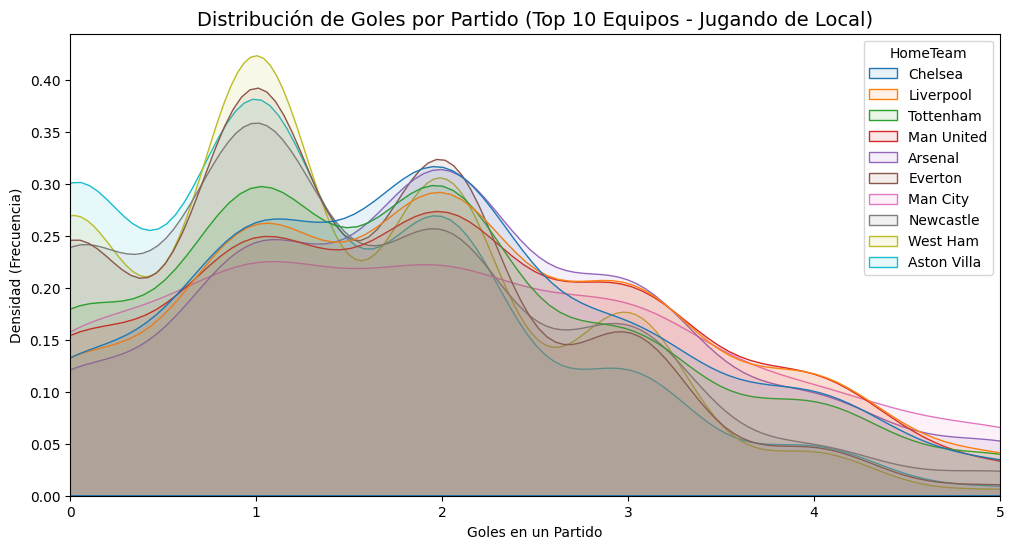

In [ ]:
# 3. Análisis de Consistencia (Skeptical Check)
# ¿El Top 10 es consistente o depende de rachas?
# Filtramos el dataframe original para tener solo partidos de estos 10 equipos
df_top10 = df[df['HomeTeam'].isin(top_10_teams.index)]

plt.figure(figsize=(12, 6))
sb.kdeplot(data=df_top10, x='FullTimeHomeGoals', hue='HomeTeam', common_norm=False, fill=True, alpha=0.1)
plt.title('Distribución de Goles por Partido (Top 10 Equipos - Jugando de Local)', fontsize=14)
plt.xlabel('Goles en un Partido')
plt.ylabel('Densidad (Frecuencia)')
plt.xlim(0, 5) # Limitamos a 5 goles para ver mejor la masa de datos
plt.show()


**Interpretación Final (Densidad de Goles - Top 10):** El gráfico de densidad revela que incluso los equipos más goleadores tienen su curva centrada entre 1 y 2 goles por partido. La extensión de la curva hacia la derecha nos muestra la varianza de equipos de élite, demostrando que aunque todos pertenezcan al Top 10, algunos tienen una mayor probabilidad matemática de lograr goleadas (3, 4 o más goles) en comparación con el resto.


In [ ]:
# 1. Calcular puntos (3 por ganar, 1 por empate)
df['HomePoints'] = df['FullTimeResult'].apply(lambda x: 3 if x == 'H' else (1 if x == 'D' else 0))
df['AwayPoints'] = df['FullTimeResult'].apply(lambda x: 3 if x == 'A' else (1 if x == 'D' else 0))

# 2. Agrupar por equipo
pts_home = df.groupby('HomeTeam')['HomePoints'].sum()
pts_away = df.groupby('AwayTeam')['AwayPoints'].sum()

# 3. Crear DataFrame comparativo y filtrar Top 10
fortaleza_df = pd.DataFrame({'Local': pts_home, 'Visitante': pts_away})
fortaleza_df['Total'] = fortaleza_df['Local'] + fortaleza_df['Visitante']
fortaleza_df = fortaleza_df.sort_values('Total', ascending=False).head(10)

# 4. Gráfico de barras apiladas
fortaleza_df[['Local', 'Visitante']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2c3e50', '#e74c3c'])
plt.title('Puntos Totales: ¿Qué tan dependientes son de la Localía? (Top 10)', fontsize=14)
plt.ylabel('Puntos Acumulados')
plt.xlabel('Equipo')
plt.legend(title='Condición')
plt.xticks(rotation=45)
plt.show()

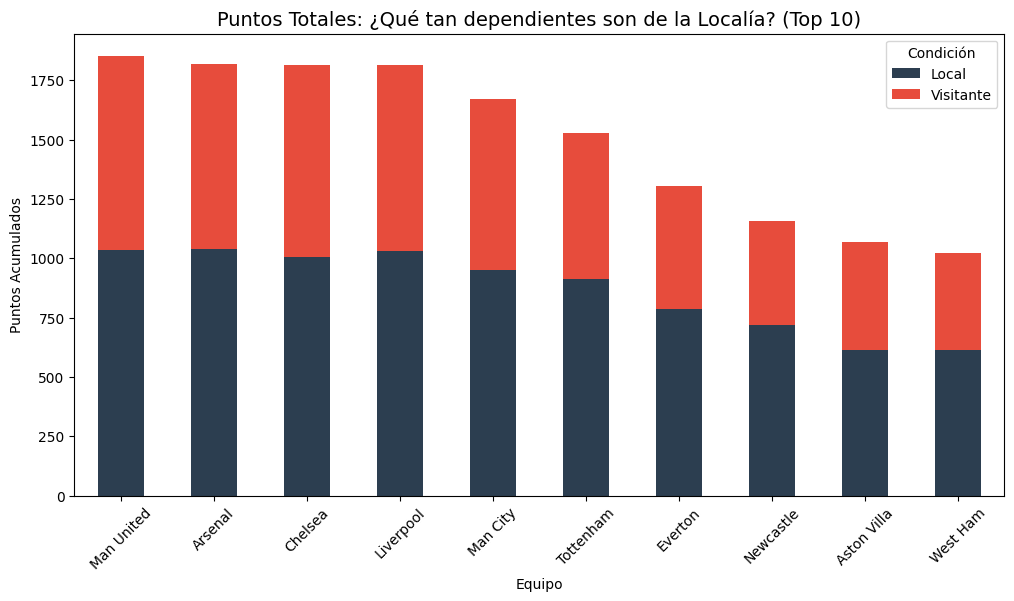

In [ ]:
# 1. Calcular puntos (3 por ganar, 1 por empate)
df['HomePoints'] = df['FullTimeResult'].apply(lambda x: 3 if x == 'H' else (1 if x == 'D' else 0))
df['AwayPoints'] = df['FullTimeResult'].apply(lambda x: 3 if x == 'A' else (1 if x == 'D' else 0))

# 2. Agrupar por equipo
pts_home = df.groupby('HomeTeam')['HomePoints'].sum()
pts_away = df.groupby('AwayTeam')['AwayPoints'].sum()

# 3. Crear DataFrame comparativo y filtrar Top 10
fortaleza_df = pd.DataFrame({'Local': pts_home, 'Visitante': pts_away})
fortaleza_df['Total'] = fortaleza_df['Local'] + fortaleza_df['Visitante']
fortaleza_df = fortaleza_df.sort_values('Total', ascending=False).head(10)

# 4. Gráfico de barras apiladas
fortaleza_df[['Local', 'Visitante']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2c3e50', '#e74c3c'])
plt.title('Puntos Totales: ¿Qué tan dependientes son de la Localía? (Top 10)', fontsize=14)
plt.ylabel('Puntos Acumulados')
plt.xlabel('Equipo')
plt.legend(title='Condición')
plt.xticks(rotation=45)
plt.show()


**Análisis del Gráfico:**
El presente análisis desglosa el origen de los puntos de los 10 equipos con mejor rendimiento en el dataset. Asignando los puntos correspondientes por victoria (3) y empate (1), comparamos el desempeño de cada equipo jugando como Local frente a su desempeño como Visitante.

La visualización en barras apiladas evidencia la estructura del éxito de estos equipos. Permite identificar rápidamente qué clubes tienen una alta dependencia de su estadio local para sumar puntos, y cuáles destacan por ser rivales formidables incluso fuera de casa, mostrando un rendimiento más simétrico en ambas condiciones.
